In [23]:
import glob
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import random

In [24]:
data_dir = "../data/raw/labeled/"
file_paths = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

files_df = pd.DataFrame({
    "full_path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
})

files_df["surface_id"] = files_df["filename"].str.extract(r"SurfaceTypeID_(\d+)").astype("Int64")

files_df.head(2) 

,full_path,filename,surface_id
0,../data/raw/labeled/USA/SurfaceTypeID_9/2019-0...,2019-02-27_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9
1,../data/raw/labeled/USA/SurfaceTypeID_9/2019-0...,2019-09-02_SurfaceTypeID_9_SamsungGalaxyS7_exp...,9


In [25]:
surface_types = pd.read_csv('../data/metadata/surface_types.csv')
surface_types.head(2)

,surface_id,surface_name
0,1,Paving Blocks (Smooth) (Red)
1,2,Concrete Sidewalk


# Frequency calculation

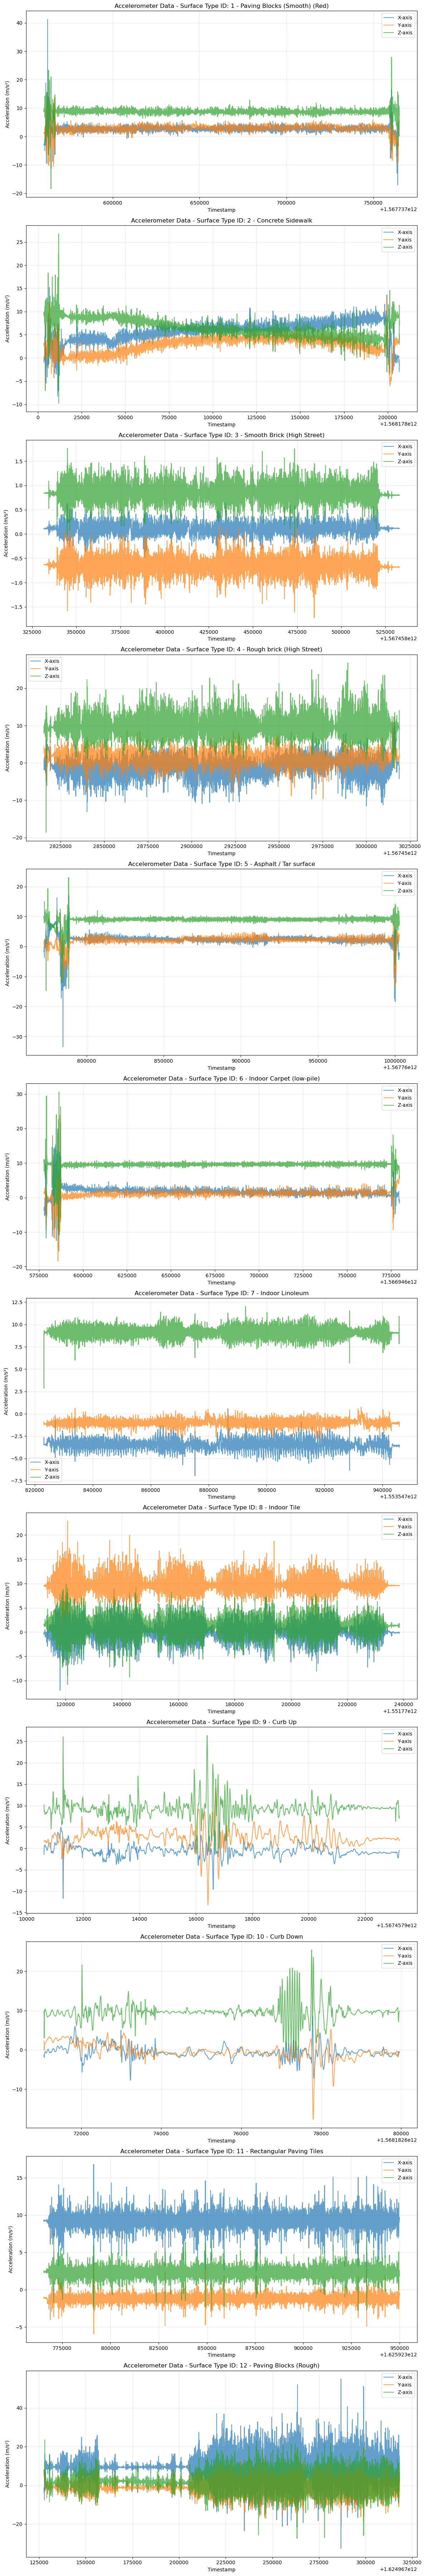

In [26]:
# Get unique surface IDs
unique_surface_ids = files_df['surface_id'].unique()

# Create subplots for each surface type
fig, axes = plt.subplots(len(unique_surface_ids), 1, figsize=(12, 6 * len(unique_surface_ids)))

# Handle case where there's only one surface type
if len(unique_surface_ids) == 1:
    axes = [axes]

for idx, surface_id in enumerate(sorted(unique_surface_ids)):
    # Get the first file for this surface type
    surface_files = files_df[files_df['surface_id'] == surface_id]
    if len(surface_files) > 1:
        file_path_temp = surface_files.iloc[1]['full_path']
        
        # Load and filter accelerometer data
        df_temp = pd.read_csv(file_path_temp)
        accel_temp = df_temp[df_temp['sensorName'] == 'Accelerometer']
        
        # Plot on the corresponding subplot
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueX'], label='X-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueY'], label='Y-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueZ'], label='Z-axis', alpha=0.7)
        axes[idx].set_xlabel('Timestamp')
        axes[idx].set_ylabel('Acceleration (m/s²)')
        # Get surface name from surface_types dictionary
        surface_name = surface_types[surface_types['surface_id'] == surface_id]['surface_name'].values[0]
        axes[idx].set_title(f'Accelerometer Data - Surface Type ID: {surface_id} - {surface_name}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trimming

In [27]:
def trim_signal(data, trim_percent=0.1):
   
    # Calculate the number of samples to trim from each end
    trim_count = int(len(data) * trim_percent)
    # Trim the signal
    trimmed_data = data[trim_count:-trim_count].copy()
            

    return trimmed_data

Processing file: ../data/raw/labeled/Vietnam/SurfaceTypeID_1/2021-07-05_SurfaceTypeID_1_RedMi_Note7-exp3_ICM20607.csv for surface ID: 1
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_2/2019-09-02_SurfaceTypeID_2_SamsungGalaxyS7_exp9_subject9.csv for surface ID: 2
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyS7_exp160_subject2.csv for surface ID: 3
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_4/2019-09-02_SurfaceTypeID_4_SamsungGalaxyS7_exp81_subject1.csv for surface ID: 4
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_5/2019-02-27_SurfaceTypeID_5_SamsungGalaxyJ7_exp5_subject17.csv for surface ID: 5
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_6/2019-08-27_SurfaceTypeID_6_SamsungGalaxyJ7_exp8_subject4.csv for surface ID: 6
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_7/2019-02-12_SurfaceTypeID_7_SamsungGalaxyJ7_exp5_subject3.csv for surface ID: 7
Processing file: ../data/raw/labeled/Vietnam

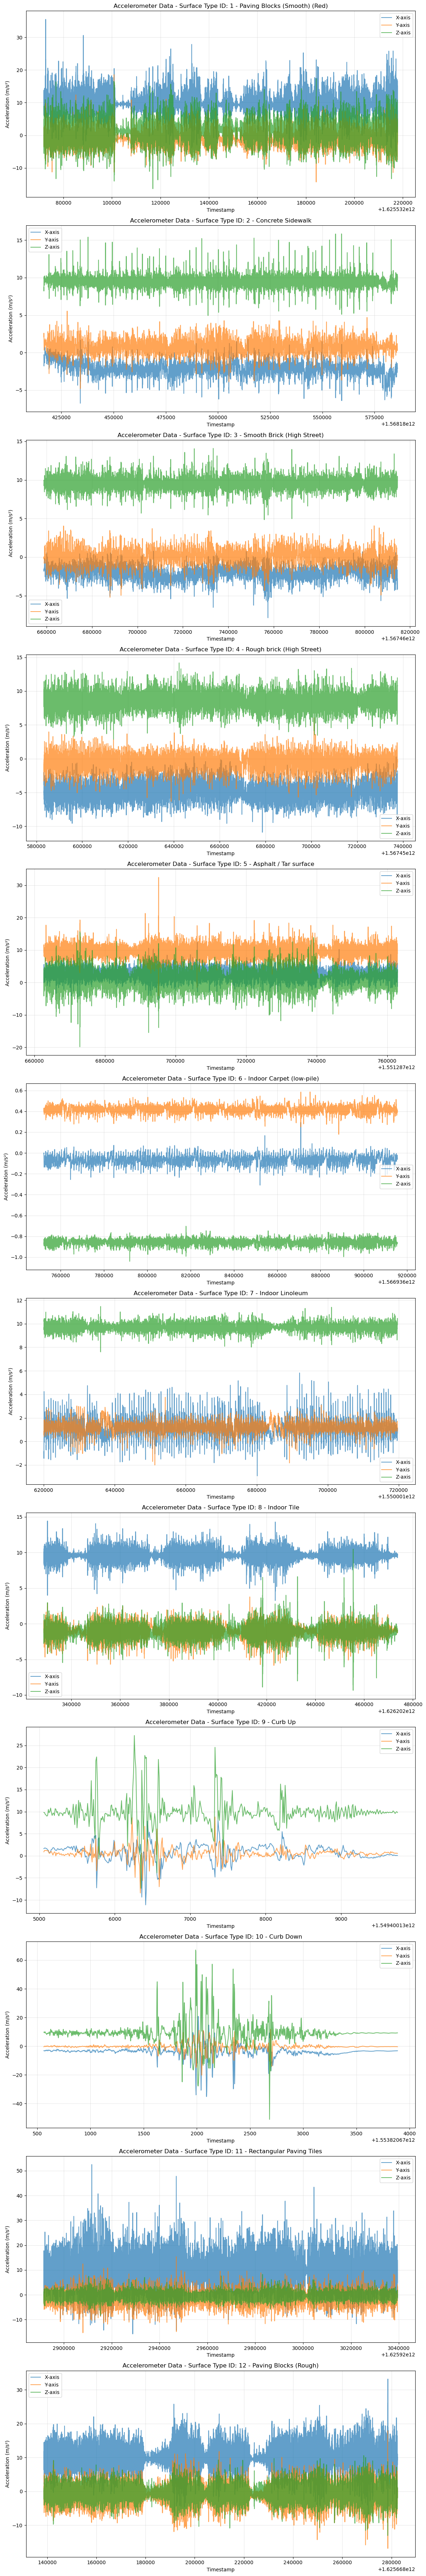

In [28]:
# Get unique surface IDs
unique_surface_ids = files_df['surface_id'].unique()

# Create subplots for each surface type
fig, axes = plt.subplots(len(unique_surface_ids), 1, figsize=(12, 6 * len(unique_surface_ids)))

# Handle case where there's only one surface type
if len(unique_surface_ids) == 1:
    axes = [axes]

for idx, surface_id in enumerate(sorted(unique_surface_ids)):
    # Get the first file for this surface type
    surface_files = files_df[files_df['surface_id'] == surface_id]
    
    if len(surface_files) > 0:
        file_id = random.randint(0, len(surface_files)-1)
        file_path_temp = surface_files.iloc[file_id]['full_path']
        print(f"Processing file: {file_path_temp} for surface ID: {surface_id}")
        
        # Load and filter accelerometer data
        df_temp = pd.read_csv(file_path_temp)
        accel_temp = df_temp[df_temp['sensorName'] == 'Accelerometer']
        
        
        # Trim 10% from start and end
        accel_temp = trim_signal(accel_temp, trim_percent=0.10)
        
        # Plot on the corresponding subplot
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueX'], label='X-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueY'], label='Y-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueZ'], label='Z-axis', alpha=0.7)
        axes[idx].set_xlabel('Timestamp')
        axes[idx].set_ylabel('Acceleration (m/s²)')
        # Get surface name from surface_types dictionary
        surface_name = surface_types[surface_types['surface_id'] == surface_id]['surface_name'].values[0]
        axes[idx].set_title(f'Accelerometer Data - Surface Type ID: {surface_id} - {surface_name}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

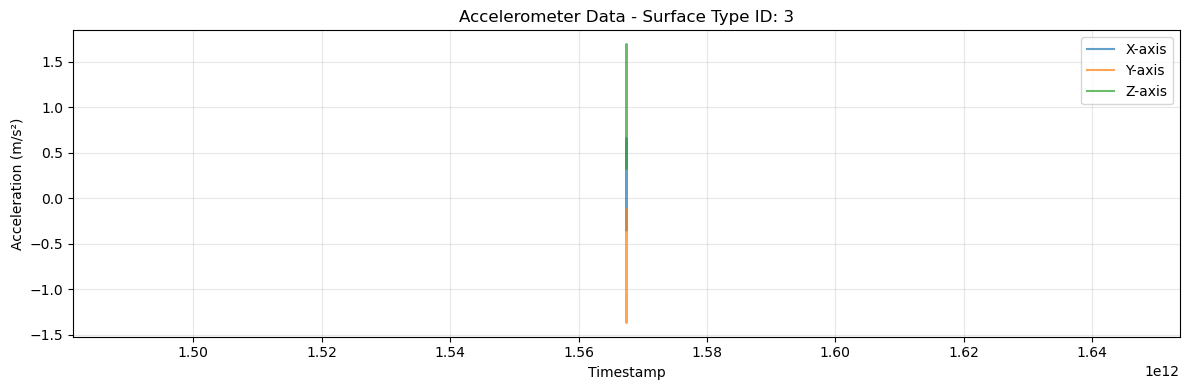

In [29]:
file_path_plot = "../data/raw/labeled/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyJ7_exp158_subject6.csv"
df_plot = pd.read_csv(file_path_plot)
accel_plot = df_plot[df_plot["sensorName"] == "Accelerometer"]

plt.figure(figsize=(12, 4))
plt.plot(accel_plot["timestamp"], accel_plot["valueX"], label="X-axis", alpha=0.7)
plt.plot(accel_plot["timestamp"], accel_plot["valueY"], label="Y-axis", alpha=0.7)
plt.plot(accel_plot["timestamp"], accel_plot["valueZ"], label="Z-axis", alpha=0.7)
plt.xlabel("Timestamp")
plt.ylabel("Acceleration (m/s²)")
plt.title("Accelerometer Data - Surface Type ID: 3")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Butterworth Fileter

In [30]:
from scipy.signal import butter, filtfilt

# Remove Gravity Componenets
def butter_highpass_filter(data, cutoff=0.3, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high')

    return filtfilt(b, a, data)    

# Remove high frequency sensor noise
def butter_lowpass_filter(data, cutoff=25, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')

    return filtfilt(b, a, data)

def run_butterworth(data):
    accel_sampling_freq = 100  # Assuming 100 Hz sampling frequency

    filtered_x = butter_highpass_filter(data['valueX'].values, cutoff=0.3, fs=accel_sampling_freq)
    filtered_y = butter_highpass_filter(data['valueY'].values, cutoff=0.3, fs=accel_sampling_freq)
    filtered_z = butter_highpass_filter(data['valueZ'].values, cutoff=0.3, fs=accel_sampling_freq)

    filtered_x = butter_lowpass_filter(filtered_x, cutoff=25, fs=accel_sampling_freq)
    filtered_y = butter_lowpass_filter(filtered_y, cutoff=25, fs=accel_sampling_freq)
    filtered_z = butter_lowpass_filter(filtered_z, cutoff=25, fs=accel_sampling_freq)
    
    data_filtered = data.copy()
    data_filtered['valueX'] = filtered_x
    data_filtered['valueY'] = filtered_y
    data_filtered['valueZ'] = filtered_z
    
    return data_filtered


Processing file: ../data/raw/labeled/Vietnam/SurfaceTypeID_1/2021-07-05_SurfaceTypeID_1_RedMi_Note7-exp3_ICM20607.csv for surface ID: 1
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_2/2019-09-02_SurfaceTypeID_2_SamsungGalaxyS7_exp5_subject5.csv for surface ID: 2
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyS7_exp159_subject1.csv for surface ID: 3
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_4/2019-09-02_SurfaceTypeID_4_SamsungGalaxyJ7_exp88_subject7.csv for surface ID: 4
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_5/2019-09-02_SurfaceTypeID_5_SamsungGalaxyS7_exp73_subject7.csv for surface ID: 5
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_6/2019-08-27_SurfaceTypeID_6_SamsungGalaxyJ7_exp1_subject1.csv for surface ID: 6
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_7/2019-09-08_SurfaceTypeID_7_SamsungGalaxyS7_exp4_subject2.csv for surface ID: 7
Processing file: ../data/raw/labeled/USA/Sur

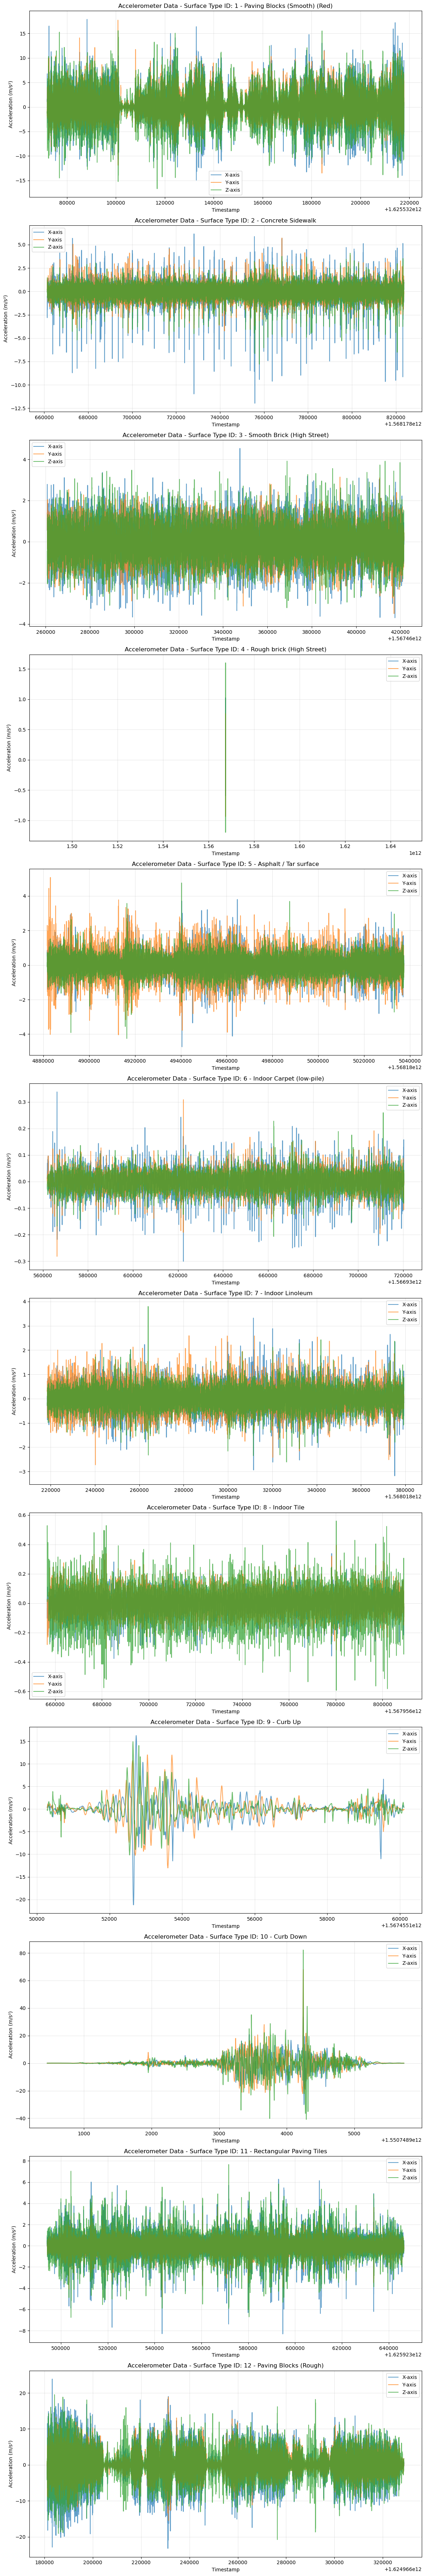

In [31]:
# Get unique surface IDs
unique_surface_ids = files_df['surface_id'].unique()

# Create subplots for each surface type
fig, axes = plt.subplots(len(unique_surface_ids), 1, figsize=(12, 6 * len(unique_surface_ids)))

# Handle case where there's only one surface type
if len(unique_surface_ids) == 1:
    axes = [axes]

for idx, surface_id in enumerate(sorted(unique_surface_ids)):
    # Get the first file for this surface type
    surface_files = files_df[files_df['surface_id'] == surface_id]
    
    if len(surface_files) > 0:
        file_id = random.randint(0, len(surface_files)-1)
        file_path_temp = surface_files.iloc[file_id]['full_path']
        print(f"Processing file: {file_path_temp} for surface ID: {surface_id}")
        
        # Load and filter accelerometer data
        df_temp = pd.read_csv(file_path_temp)
        accel_temp = df_temp[df_temp['sensorName'] == 'Accelerometer']
        
        
        # Trim 10% from start and end
        accel_temp = trim_signal(accel_temp, trim_percent=0.10)
        accel_temp = run_butterworth(accel_temp)
        
        # Plot on the corresponding subplot
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueX'], label='X-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueY'], label='Y-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueZ'], label='Z-axis', alpha=0.7)
        axes[idx].set_xlabel('Timestamp')
        axes[idx].set_ylabel('Acceleration (m/s²)')
        # Get surface name from surface_types dictionary
        surface_name = surface_types[surface_types['surface_id'] == surface_id]['surface_name'].values[0]
        axes[idx].set_title(f'Accelerometer Data - Surface Type ID: {surface_id} - {surface_name}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hampel filter
Remove impluse noise 

In [32]:
from scipy import stats

def hampel_filter(signal, window_size=10, n_sigmas=3):
    new_signal = signal.copy()
    L = len(signal)
    
    for i in range(window_size, L-window_size):
        window = signal[i-window_size:i+window_size]
        median = np.median(window)
        mad = stats.median_abs_deviation(window)
        
        if abs(signal[i] - median) > n_sigmas * mad:
            new_signal[i] = median
            
    return new_signal

def run_hampel(data):
    data_filtered = data.copy()
    data_filtered['valueX'] = hampel_filter(data['valueX'].values, window_size=10, n_sigmas=3)
    data_filtered['valueY'] = hampel_filter(data['valueY'].values, window_size=10, n_sigmas=3)
    data_filtered['valueZ'] = hampel_filter(data['valueZ'].values, window_size=10, n_sigmas=3)
    
    return data_filtered

Processing file: ../data/raw/labeled/USA/SurfaceTypeID_1/2019-08-30_SurfaceTypeID_1_SamsungGalaxyS7_exp3_subject1.csv for surface ID: 1
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_2/2019-09-02_SurfaceTypeID_2_SamsungGalaxyS7_exp7_subject7.csv for surface ID: 2
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyS7_exp157_subject5.csv for surface ID: 3
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_4/2019-09-02_SurfaceTypeID_4_SamsungGalaxyS7_exp85_subject5.csv for surface ID: 4
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_5/2019-09-02_SurfaceTypeID_5_SamsungGalaxyS7_exp79_subject2.csv for surface ID: 5
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_6/2019-01-07_SurfaceTypeID_6_SamsungGalaxyS9_exp2_subject1.csv for surface ID: 6
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_7/2019-02-25_SurfaceTypeID_7_SamsungGalaxyS7_exp2_subject16.csv for surface ID: 7
Processing file: ../data/raw/labeled/USA/Su

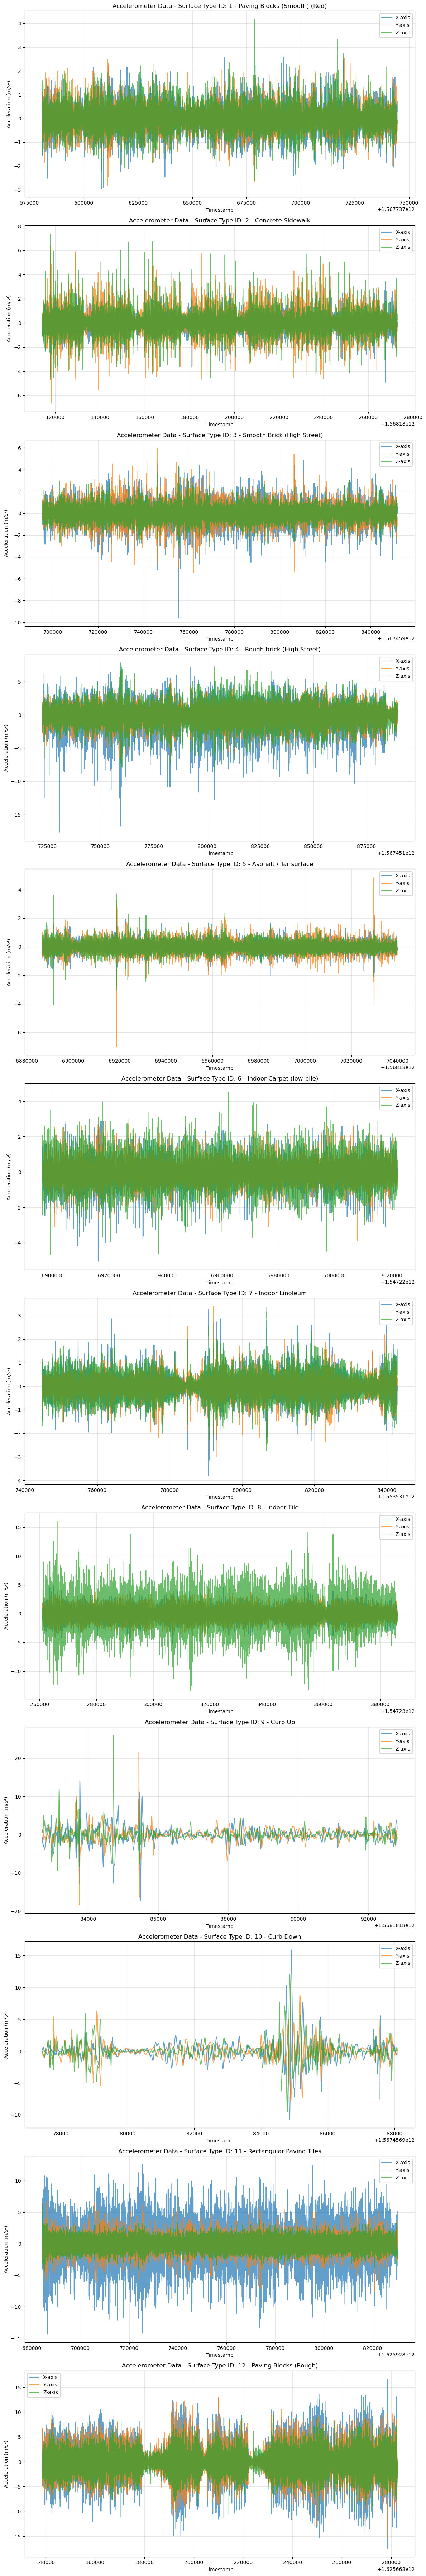

In [33]:
# Get unique surface IDs
unique_surface_ids = files_df['surface_id'].unique()

# Create subplots for each surface type
fig, axes = plt.subplots(len(unique_surface_ids), 1, figsize=(12, 6 * len(unique_surface_ids)))

# Handle case where there's only one surface type
if len(unique_surface_ids) == 1:
    axes = [axes]

for idx, surface_id in enumerate(sorted(unique_surface_ids)):
    # Get the first file for this surface type
    surface_files = files_df[files_df['surface_id'] == surface_id]
    
    if len(surface_files) > 0:
        file_id = random.randint(0, len(surface_files)-1)
        file_path_temp = surface_files.iloc[file_id]['full_path']
        print(f"Processing file: {file_path_temp} for surface ID: {surface_id}")
        
        # Load and filter accelerometer data
        df_temp = pd.read_csv(file_path_temp)
        accel_temp = df_temp[df_temp['sensorName'] == 'Accelerometer']
        
        
        # Trim 10% from start and end
        accel_temp = trim_signal(accel_temp, trim_percent=0.10)
        accel_temp = run_butterworth(accel_temp)
        accel_temp = run_hampel(accel_temp)

        
        # Plot on the corresponding subplot
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueX'], label='X-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueY'], label='Y-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueZ'], label='Z-axis', alpha=0.7)
        axes[idx].set_xlabel('Timestamp')
        axes[idx].set_ylabel('Acceleration (m/s²)')
        # Get surface name from surface_types dictionary
        surface_name = surface_types[surface_types['surface_id'] == surface_id]['surface_name'].values[0]
        axes[idx].set_title(f'Accelerometer Data - Surface Type ID: {surface_id} - {surface_name}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Remove stalled region

In [34]:
def remove_stalled_regions(
    df: pd.DataFrame,
    sampling_rate: int = 100,
    change_threshold: float = 1e-5,
    min_stall_seconds: float = 2.0
) -> pd.DataFrame:

    df = df.copy()

    # Compute magnitude
    magnitude = np.sqrt(df['valueX']**2 + df['valueY']**2 + df['valueZ']**2)

    # Compute first-order difference (absolute derivative)
    diff = magnitude.diff().abs().fillna(0)

    # Identify flat points
    flat_mask = diff < change_threshold

    # Convert duration to samples
    min_samples = int(min_stall_seconds * sampling_rate)

    # Identify long flat regions
    remove_mask = np.zeros(len(df), dtype=bool)
    start_idx = None

    for i, is_flat in enumerate(flat_mask):
        if is_flat and start_idx is None:
            start_idx = i
        elif not is_flat and start_idx is not None:
            if i - start_idx >= min_samples:
                remove_mask[start_idx:i] = True
            start_idx = None

    # Handle case where stalled region extends to end
    if start_idx is not None and len(df) - start_idx >= min_samples:
        remove_mask[start_idx:] = True

    #Return cleaned dataframe
    return df.loc[~remove_mask].reset_index(drop=True)

Processing file: ../data/raw/labeled/USA/SurfaceTypeID_1/2019-08-30_SurfaceTypeID_1_SamsungGalaxyS7_exp3_subject1.csv for surface ID: 1
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_2/2019-02-27_SurfaceTypeID_2_SamsungGalaxyS7_exp3_subject19.csv for surface ID: 2
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyS7_exp157_subject5.csv for surface ID: 3
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_4/2019-09-02_SurfaceTypeID_4_SamsungGalaxyS7_exp87_subject9.csv for surface ID: 4
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_5/2019-09-02_SurfaceTypeID_5_SamsungGalaxyJ7_exp59_subject10.csv for surface ID: 5
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_6/2019-02-25_SurfaceTypeID_6_SamsungGalaxyJ7_exp4_subject15.csv for surface ID: 6
Processing file: ../data/raw/labeled/USA/SurfaceTypeID_7/2019-02-12_SurfaceTypeID_7_SamsungGalaxyJ7_exp14_subject5.csv for surface ID: 7
Processing file: ../data/raw/labeled/USA

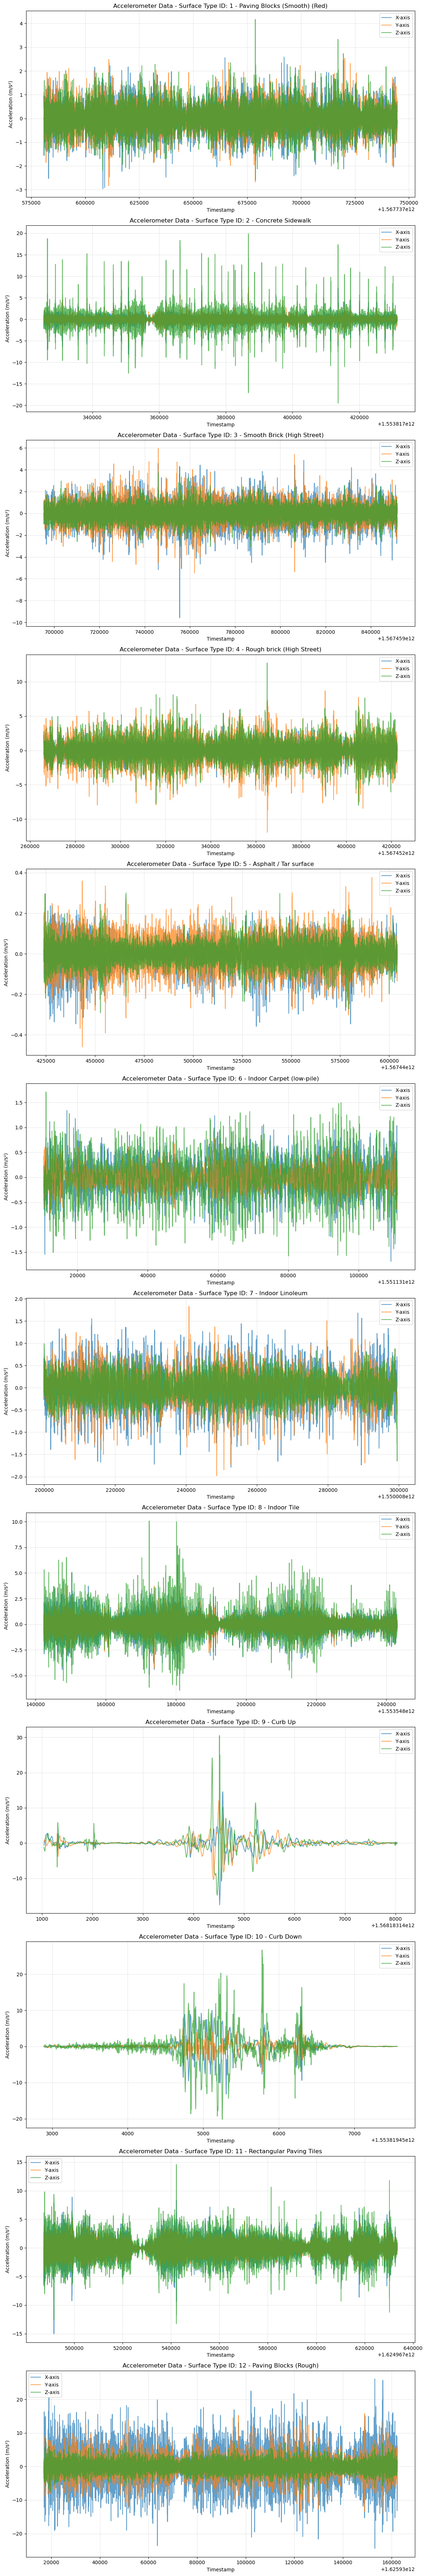

In [35]:
# Get unique surface IDs
unique_surface_ids = files_df['surface_id'].unique()

# Create subplots for each surface type
fig, axes = plt.subplots(len(unique_surface_ids), 1, figsize=(12, 6 * len(unique_surface_ids)))

# Handle case where there's only one surface type
if len(unique_surface_ids) == 1:
    axes = [axes]

for idx, surface_id in enumerate(sorted(unique_surface_ids)):
    # Get the first file for this surface type
    surface_files = files_df[files_df['surface_id'] == surface_id]
    
    if len(surface_files) > 0:
        file_id = random.randint(0, len(surface_files)-1)
        file_path_temp = surface_files.iloc[file_id]['full_path']
        print(f"Processing file: {file_path_temp} for surface ID: {surface_id}")
        
        # Load and filter accelerometer data
        df_temp = pd.read_csv(file_path_temp)
        accel_temp = df_temp[df_temp['sensorName'] == 'Accelerometer']
        
        
        # Trim 10% from start and end
        accel_temp = trim_signal(accel_temp, trim_percent=0.10)
        accel_temp = run_butterworth(accel_temp)
        accel_temp = run_hampel(accel_temp)
        accel_temp = remove_stalled_regions(accel_temp)

        
        # Plot on the corresponding subplot
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueX'], label='X-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueY'], label='Y-axis', alpha=0.7)
        axes[idx].plot(accel_temp['timestamp'], accel_temp['valueZ'], label='Z-axis', alpha=0.7)
        axes[idx].set_xlabel('Timestamp')
        axes[idx].set_ylabel('Acceleration (m/s²)')
        # Get surface name from surface_types dictionary
        surface_name = surface_types[surface_types['surface_id'] == surface_id]['surface_name'].values[0]
        axes[idx].set_title(f'Accelerometer Data - Surface Type ID: {surface_id} - {surface_name}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Process all files

# Preprocessing Steps

1. **Load raw CSV files** and collect metadata (paths, filenames, surface IDs).
2. **Select sensor data** (Accelerometer or Gyroscope) from each file.
3. **Trim signal edges** to remove start/end artifacts (default: 10%).
4. **Butterworth filtering**  
    - High-pass to remove gravity components.  
    - Low-pass to suppress high-frequency noise.
5. **Hampel filter** to remove impulse noise on each axis.
6. **Remove stalled regions** (flat/motionless segments) based on magnitude changes.
8. **Save processed files** with sensor-specific suffixes (e.g., `_Accelerometer`, `_Gyroscope`).

## Filters and processing methods

In [36]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from scipy import stats
from scipy.ndimage import label

# Trimping function to remove start/end artifacts
def trim_signal(data, trim_percent=0.1):
    """Trim a percentage of samples from the start and end of the signal."""
    trim_count = int(len(data) * trim_percent)

    return data[trim_count:-trim_count].reset_index(drop=True)

# Butterworth filter design using SOS for stability
def _design_butterworth_filter(cutoff, fs, btype, order=4):
    """Design a Butterworth filter and return SOS coefficients."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    return butter(order, normal_cutoff, btype=btype, output='sos')


def run_butterworth(data, fs = 100, highpass_cutoff=0.3, lowpass_cutoff=25, order=4):
    """
    Apply bandpass filtering (highpass + lowpass) to X, Y, Z accelerometer columns.
    Uses SOS format for numerical stability.
    """
    # Design filters once, reuse across axes
    sos_high = _design_butterworth_filter(highpass_cutoff, fs, btype='high', order=order)
    sos_low  = _design_butterworth_filter(lowpass_cutoff,  fs, btype='low',  order=order)

    cols = ['valueX', 'valueY', 'valueZ']
    raw = data[cols].values  # (N, 3) — process all axes at once

    filtered = sosfiltfilt(sos_high, raw, axis=0)
    filtered = sosfiltfilt(sos_low,  filtered, axis=0)

    data_filtered = data.copy()
    data_filtered[cols] = filtered

    return data_filtered


# Hampel filter implementation
def _hampel_filter_vectorized(signal: np.ndarray, window_size: int = 10, n_sigmas: float = 3) -> np.ndarray:
    """
    Fully vectorized Hampel filter — significantly faster for large arrays.
    Uses stride tricks to build a sliding window matrix in one operation.
    """
    if not isinstance(signal, np.ndarray):
        signal = np.asarray(signal, dtype=float)

    L = len(signal)
    new_signal = signal.copy()

    # Build sliding window view using stride tricks (zero-copy)
    win_full = 2 * window_size + 1
    shape = (L - 2 * window_size, win_full)
    strides = (signal.strides[0], signal.strides[0])
    windows = np.lib.stride_tricks.as_strided(signal, shape=shape, strides=strides)

    medians = np.median(windows, axis=1)
    mads = stats.median_abs_deviation(windows, axis=1)

    threshold = n_sigmas * np.maximum(mads, 1e-10)
    center_vals = signal[window_size : L - window_size]
    outlier_mask = np.abs(center_vals - medians) > threshold 


    new_signal[window_size : L - window_size][outlier_mask] = medians[outlier_mask]

    return new_signal


def run_hampel(data, vectorized: bool = True):
    """
    Apply Hampel filter to valueX, valueY, valueZ columns.

    Args:
        data: DataFrame with columns valueX, valueY, valueZ
        vectorized: Use fast vectorized implementation (default: True)
    """

    required_cols = ['valueX', 'valueY', 'valueZ']
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data_filtered = data.copy()

    # Process all columns in a single loop instead of repeating code
    for col in required_cols:
        data_filtered[col] = _hampel_filter_vectorized(data[col].values, window_size=10, n_sigmas=3)

    return data_filtered

# Remove stalled (flat/motionless) regions from accelerometer data
def remove_stalled_regions(
    df: pd.DataFrame,
    sampling_rate: int = 100,
    change_threshold: float = 1e-5,
    min_stall_seconds: float = 2.0
) -> pd.DataFrame:
    """
    Remove stalled (flat/motionless) regions from accelerometer data.

    Args:
        df: DataFrame with columns valueX, valueY, valueZ
        sampling_rate: Samples per second
        change_threshold: Max diff magnitude to consider a point "flat"
        min_stall_seconds: Minimum duration (seconds) to classify as a stall

    Returns:
        DataFrame with stalled regions removed and index reset
    """
    required_cols = ['valueX', 'valueY', 'valueZ']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if sampling_rate <= 0:
        raise ValueError("sampling_rate must be positive")
    if min_stall_seconds <= 0:
        raise ValueError("min_stall_seconds must be positive")

    df = df.copy()

    # Compute magnitude
    magnitude = np.sqrt(df['valueX']**2 + df['valueY']**2 + df['valueZ']**2)

    # Use np.diff directly (faster than pandas .diff())
    diff = np.empty(len(magnitude))
    diff[0] = 0.0
    diff[1:] = np.abs(np.diff(magnitude))

    # Identify flat points
    flat_mask = diff < change_threshold

    # Convert duration to samples
    min_samples = int(min_stall_seconds * sampling_rate)

    # instead of Python for-loop over every sample
    labeled_array, num_features = label(flat_mask)

    remove_mask = np.zeros(len(df), dtype=bool)

    for region_id in range(1, num_features + 1):
        region_indices = np.where(labeled_array == region_id)[0]
        if len(region_indices) >= min_samples:
            remove_mask[region_indices] = True

    return df.loc[~remove_mask].reset_index(drop=True)

In [37]:
from scipy.signal import resample_poly
from math import gcd

def resample_to_target_freq(accel, target_freq=100, sensor_name='Accelerometer'):
    AXIS_COLS = ['valueX', 'valueY', 'valueZ']

    accel = accel[pd.to_numeric(accel['timestamp'], errors='coerce').notna()].copy()
    accel['timestamp'] = accel['timestamp'].astype(float)

    if len(accel) < 2:
        print(f"  [{sensor_name}] Too few rows, skipping.")
        return None

    diffs = np.diff(accel['timestamp'].values)
    diffs_valid = diffs[diffs > 0]

    if len(diffs_valid) == 0:
        print(f"  [{sensor_name}] All timestamps identical, skipping.")
        return None  # Signal to outer loop to skip this file

    median_diff = np.median(diffs_valid)
    max_ts = accel['timestamp'].max()
    if max_ts > 1e18:
        native_freq = 1_000_000_000 / median_diff
    elif max_ts > 1e15:
        native_freq = 1_000_000 / median_diff
    elif max_ts > 1e12:
        native_freq = 1_000 / median_diff
    else:
        native_freq = 1 / median_diff
    native_freq = round(native_freq)

    if native_freq == target_freq:
        return accel

    native_freq = round(native_freq)
    
    if native_freq < 1:
        print(f"  [{sensor_name}] Could not detect valid native frequency, skipping.")
        return None

    # Compute up/down ratio for polyphase resampling
    g    = gcd(target_freq, native_freq)
    up   = target_freq // g
    down = native_freq // g



    resampled = {}
    for col in AXIS_COLS:
        if col in accel.columns:
            resampled[col] = resample_poly(accel[col].values, up, down)

    # Reconstruct evenly-spaced timestamps to match resampled length
    n_target = len(resampled[next(iter(resampled))])
    t_start = accel['timestamp'].iloc[0]
    t_end   = accel['timestamp'].iloc[-1]
    resampled['timestamp'] = np.linspace(t_start, t_end, n_target)

    df_resampled = pd.DataFrame(resampled)
    for col in accel.columns:
        if col not in df_resampled.columns:
            df_resampled[col] = accel[col].iloc[0]

    df_resampled = df_resampled[accel.columns]

    # print(f"  [{sensor_name}] {native_freq} Hz → {target_freq} Hz ({len(accel)} → {n_target} samples)")
    return df_resampled

## Procesing

In [38]:
data_dir = "../data/raw/labeled/"
file_paths = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

files_df = pd.DataFrame({
    "full_path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
})

files_df["surface_id"] = files_df["filename"].str.extract(r"SurfaceTypeID_(\d+)").astype("Int64")

files_df.head(2) 

,full_path,filename,surface_id
0,../data/raw/labeled/USA/SurfaceTypeID_9/2019-0...,2019-02-27_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9
1,../data/raw/labeled/USA/SurfaceTypeID_9/2019-0...,2019-09-02_SurfaceTypeID_9_SamsungGalaxyS7_exp...,9


In [39]:
from tqdm import tqdm

data_dir = "../data/raw/"
processed_root = "../data/processed/"


for i, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    in_path = row["full_path"]
    rel_path = os.path.relpath(in_path, data_dir)
    out_path = os.path.join(processed_root, rel_path)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    df = pd.read_csv(in_path)
    accel = df[df["sensorName"].str.lower() == "accelerometer"].copy()

    # only keep sensorName, surface_id, valueX, valueY, valueZ, timestamp columns
    accel = accel[["sensorName", "valueX", "valueY", "valueZ", "timestamp"]]

    accel = resample_to_target_freq(accel, target_freq=100, sensor_name="Accelerometer")

    if accel is None:
        continue

    accel = trim_signal(accel, trim_percent=0.10)
    accel = run_butterworth(accel)
    accel = run_hampel(accel)
    accel = remove_stalled_regions(accel)

    # Add "_Accelerometer" suffix before the .csv extension
    out_path_base, out_path_ext = os.path.splitext(out_path)
    out_path_final = f"{out_path_base}_Accelerometer{out_path_ext}"
    
    accel.to_csv(out_path_final, index=False)

Processing files:   3%|▎         | 20/678 [00:00<00:07, 93.50it/s]

  [Accelerometer] All timestamps identical, skipping.


Processing files:   8%|▊         | 54/678 [00:00<00:05, 104.52it/s]

  [Accelerometer] All timestamps identical, skipping.
  [Accelerometer] All timestamps identical, skipping.


Processing files:  14%|█▍        | 94/678 [00:00<00:04, 121.52it/s]

...

Processing files:  86%|████████▌ | 581/678 [00:23<00:08, 11.67it/s]

  [Accelerometer] All timestamps identical, skipping.


Processing files:  94%|█████████▎| 634/678 [00:29<00:04, 10.86it/s]

  [Accelerometer] All timestamps identical, skipping.


Processing files: 100%|██████████| 678/678 [00:34<00:00, 19.42it/s]


In [40]:
from tqdm import tqdm

data_dir = "../data/raw/"
processed_root = "../data/processed/"


for i, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    in_path = row["full_path"]
    rel_path = os.path.relpath(in_path, data_dir)
    out_path = os.path.join(processed_root, rel_path)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    df = pd.read_csv(in_path)
    gyro_data = df[df["sensorName"].str.lower() == "gyroscope"].copy()

    # only keep sensorName, surface_id, valueX, valueY, valueZ, timestamp columns
    gyro_data = gyro_data[["sensorName", "valueX", "valueY", "valueZ", "timestamp"]]

    gyro_data = resample_to_target_freq(gyro_data, target_freq=100, sensor_name="Gyroscope")

    if gyro_data is None:
        continue

    gyro_data = trim_signal(gyro_data, trim_percent=0.10)
    gyro_data = run_butterworth(gyro_data)
    gyro_data = run_hampel(gyro_data)
    gyro_data = remove_stalled_regions(gyro_data)

    # Add "_Gyroscope" suffix before the .csv extension
    out_path_base, out_path_ext = os.path.splitext(out_path)
    out_path_final = f"{out_path_base}_Gyroscope{out_path_ext}"
    
    gyro_data.to_csv(out_path_final, index=False)

Processing files:   3%|▎         | 22/678 [00:00<00:06, 103.49it/s]

  [Gyroscope] All timestamps identical, skipping.
  [Gyroscope] Too few rows, skipping.


Processing files:   8%|▊         | 57/678 [00:00<00:05, 110.60it/s]

  [Gyroscope] All timestamps identical, skipping.
  [Gyroscope] Too few rows, skipping.
  [Gyroscope] All timestamps identical, skipping.


Processing files:  14%|█▍        | 95/678 [00:00<00:04, 116.95it/s]

...

Processing files:  91%|█████████▏| 620/678 [00:28<00:06,  8.64it/s]

  [Gyroscope] Too few rows, skipping.


Processing files:  94%|█████████▎| 635/678 [00:29<00:04,  9.44it/s]

  [Gyroscope] All timestamps identical, skipping.


Processing files: 100%|██████████| 678/678 [00:34<00:00, 19.64it/s]


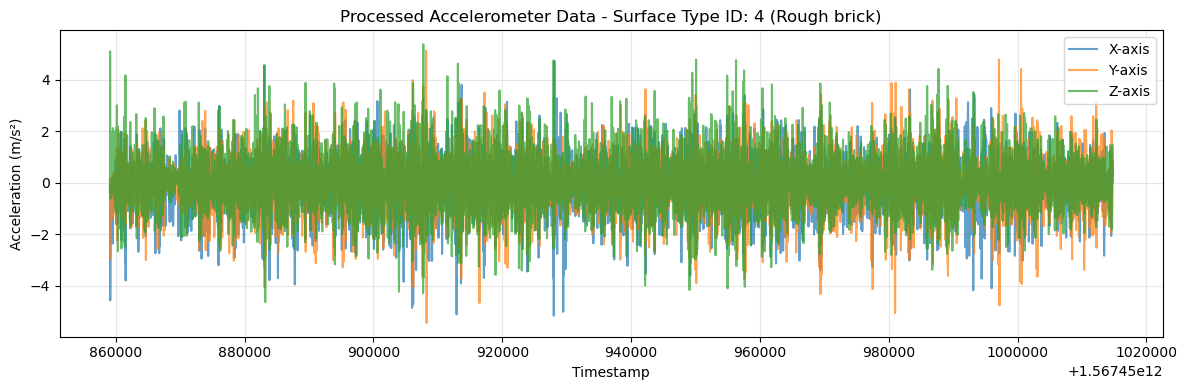

In [41]:
# Load and plot the processed accelerometer file
processed_file = "../data/processed/labeled/USA/SurfaceTypeID_4/2019-09-02_SurfaceTypeID_4_SamsungGalaxyS7_exp82_subject2_Accelerometer.csv"
df_processed = pd.read_csv(processed_file)
# Normalize the data (zero mean, unit variance) for better visualization
df_processed['valueX'] = (df_processed['valueX'] - df_processed['valueX'].mean()) / df_processed['valueX'].std()
df_processed['valueY'] = (df_processed['valueY'] - df_processed['valueY'].mean()) / df_processed['valueY'].std()
df_processed['valueZ'] = (df_processed['valueZ'] - df_processed['valueZ'].mean()) / df_processed['valueZ'].std()

plt.figure(figsize=(12, 4))
plt.plot(df_processed['timestamp'], df_processed['valueX'], label='X-axis', alpha=0.7)
plt.plot(df_processed['timestamp'], df_processed['valueY'], label='Y-axis', alpha=0.7)
plt.plot(df_processed['timestamp'], df_processed['valueZ'], label='Z-axis', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Acceleration (m/s²)')
plt.title('Processed Accelerometer Data - Surface Type ID: 4 (Rough brick)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()